In [1]:
import torch
import torch.nn.functional as F
from torch import Tensor
import numpy as np


# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────

def normalize_max_min(x: Tensor) -> Tensor:
    """
    Min-max normalize a 1-D tensor to [0, 1].
    Returns a zero tensor if x is constant (avoids division by zero).
    """
    x_min = x.min()
    x_max = x.max()
    denom = x_max - x_min
    if denom == 0:
        return torch.zeros_like(x)
    return (x - x_min) / (denom + 1e-8)

def normalize_robust(x: Tensor) -> Tensor:
    """Robust normalization with percentile clipping."""
    q_low, q_high = torch.quantile(x, torch.tensor([0.01, 0.99]))
    x_clipped = torch.clamp(x, q_low, q_high)
    return (x_clipped - q_low) / (q_high - q_low + 1e-8)


def check_arma_stationarity(ar_coeffs: Tensor) -> bool:
    """
    Stationarity for y_t = sum(phi_i y_{t-i}) + eps_t:
    roots of 1 - phi1*z - ... - phip*z^p must be outside unit circle.
    Here phi = -ar_coeffs because generation uses y[t] -= ar[i]*y[t-i-1].
    """
    if len(ar_coeffs) == 0:
        return True

    phi = (-ar_coeffs).detach().cpu().numpy()  # convert your parameterization -> standard phi

    # polynomial: 1 - phi1*z - ... - phip*z^p
    # descending powers => [-phip, ..., -phi1, 1]
    coeffs = np.concatenate((-phi[::-1], np.array([1.0], dtype=phi.dtype)))

    roots = np.roots(coeffs)
    return bool(np.all(np.abs(roots) > 1.0))


# ─────────────────────────────────────────────
# Random Walk
# ─────────────────────────────────────────────

def random_walk(
    n_samples : int,
    n_states  : int = 64,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate a bounded discrete random walk on [0, n_states]
    with reflecting walls.

    Parameters
    ----------
    n_samples : int
        Number of steps (output length = n_samples + 1).
    n_states  : int
        Upper boundary of the walk (lower boundary is 0).
    seed      : int or None
        Optional seed for reproducibility.
    device    : str or torch.device
        Target device ('cpu' or 'cuda').

    Returns
    -------
    Tensor of shape (n_samples + 1,), float32, values in [0, 1].
    """

    # Or better, use vectorized approach:
    positions = torch.cumsum(steps.float(), dim=0) + start
    positions = torch.abs(positions)  # Reflect at 0
    positions = 2 * max_pos - torch.abs(positions - max_pos)  # Reflect at max

    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    # ±1 steps with equal probability
    steps = torch.randint(
        low=0, high=2,
        size=(n_samples,),
        generator=gen,
        device=device,
    ) * 2 - 1                                       # maps {0,1} → {-1,+1}

    # Start position: random integer in [0, n_states]
    start = torch.randint(
        low=0, high=n_states + 1,
        size=(1,),
        generator=gen,
        device=device,
    ).float()

    # Build positions with reflecting boundaries via cumsum + clamp
    # We can't simply cumsum and clamp because clamping mid-sequence
    # changes subsequent steps. We use an iterative approach via
    # torch.stack after computing each clamped position.
    positions = torch.empty(n_samples + 1, dtype=torch.float32, device=device)
    positions[0] = start

    for i in range(n_samples):
        nxt = positions[i] + steps[i].float()

        # reflect at 0
        if nxt < 0.0:
            nxt = -nxt

        # reflect at max_pos
        if nxt > max_pos:
            nxt = 2.0 * max_pos - nxt

        positions[i + 1] = nxt

    return normalize_max_min(positions)


# ─────────────────────────────────────────────
# ARMA generation
# ─────────────────────────────────────────────

def generate_arma(
    ar_coeffs : Tensor,
    ma_coeffs : Tensor,
    n_samples : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate an ARMA(p, q) time series sample.

    The model is:
        y[t] = -Σ ar[i]*y[t-i]  +  ε[t]  +  Σ ma[j]*ε[t-j]

    Parameters
    ----------
    ar_coeffs : Tensor of shape (p,)  — AR coefficients (WITHOUT leading 1)
    ma_coeffs : Tensor of shape (q,)  — MA coefficients (WITHOUT leading 1)
    n_samples : int
    seed      : optional int
    device    : 'cpu' or 'cuda'

    Returns
    -------
    Tensor of shape (n_samples,), float32.
    """
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    ar = ar_coeffs.to(device=device, dtype=torch.float32)
    ma = ma_coeffs.to(device=device, dtype=torch.float32)
    p  = len(ar)
    q  = len(ma)

    # White noise
    eps = torch.randn(n_samples, generator=gen, device=device)

    # ── MA part: convolve ε with [1, ma1, ma2, ...] ──────────────────
    # We need causal convolution: ma_input[t] = ε[t] + Σ ma[j]*ε[t-j]
    ma_kernel = torch.cat([torch.ones(1, device=device), ma])   # shape (q+1,)
    # Pad left so output is same length as input (causal)
    eps_padded = F.pad(eps.view(1, 1, -1), (q, 0))             # (1,1, n+q)
    ma_out = F.conv1d(
        eps_padded,
        ma_kernel.flip(0).view(1, 1, -1),
    ).squeeze()                                                  # shape (n_samples,)

    # ── AR part: causal recursion ──────────────────────────────────────
    y = torch.zeros(n_samples, device=device)
    for t in range(n_samples):
        y[t] = ma_out[t]
        for i in range(p):
            if t - i - 1 >= 0:
                y[t] = y[t] - ar[i] * y[t - i - 1]

    return y


# ─────────────────────────────────────────────
# Main dispatcher
# ─────────────────────────────────────────────

def timeseries(
    n_samples : int,
    process   : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> tuple[Tensor, str]:
    """
    Generate a normalized synthetic time series as a PyTorch Tensor.

    Parameters
    ----------
    n_samples : int
        Number of samples.
    process   : int
        1 → Bounded Random Walk
        2 → Random ARMA(3,3) (randomized coefficients)
        3 → Fixed  ARMA(2,2) (fixed   coefficients)
    seed      : int or None
        Master seed. Derived seeds are passed to sub-functions so the
        entire call is reproducible from a single integer.
    device    : str or torch.device
        'cpu' or 'cuda'.

    Returns
    -------
    (signal, label) : (Tensor, str)
        signal — float32 Tensor of shape (n_samples,) or (n_samples+1,),
                 values in [0, 1].
        label  — descriptive string.

    Raises
    ------
    ValueError
        If process ∉ {1, 2, 3} or if ARMA coefficients yield
        a non-stationary process.
    """
    # ── Master RNG (torch) for coefficient sampling ────────────────────
    gen = torch.Generator()          # CPU generator for coefficient draws
    if seed is not None:
        gen.manual_seed(seed)

    def _child_seed() -> int:
        """Draw a reproducible child seed from the master generator."""
        return int(torch.randint(0, 2**31, (1,), generator=gen).item())

    # ── Process 1: Random Walk ─────────────────────────────────────────
    if process == 1:
        raw = random_walk(
        n_samples=n_samples,
        n_states=64,
        seed=_child_seed() if seed is not None else None,
        device=device,
        )
        return raw, 'random_walk'

    # ── Process 2: Random ARMA(3,3) ───────────────────────────────────
    elif process == 2:
        ar = torch.tensor([
            -torch.randint(840, 961, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
        ], dtype=torch.float32)

        ma = torch.tensor([
             torch.randint(5, 16, (1,), generator=gen).item() / 1000,
            -torch.randint(5, 16, (1,), generator=gen).item() / 10000,
             torch.randint(5, 16, (1,), generator=gen).item() / 10000,
        ], dtype=torch.float32)

        lab = 'rARMA(3,3)'

    # ── Process 3: Fixed ARMA(2,2) ────────────────────────────────────
    elif process == 3:
        ar  = torch.tensor([-0.03,  0.03], dtype=torch.float32)
        ma  = torch.tensor([ 0.93, -0.33], dtype=torch.float32)
        lab = 'ARMA(2,2)'

    else:
        raise ValueError(f"Unknown process '{process}'. Expected 1, 2, or 3.")

    # ── Stationarity guard ─────────────────────────────────────────────
    if not check_arma_stationarity(ar):
        raise ValueError(
            f"Non-stationary AR coefficients: {ar.tolist()}. "
            "Resample or adjust coefficient ranges."
        )

    raw = generate_arma(
        ar_coeffs=ar,
        ma_coeffs=ma,
        n_samples=n_samples,
        seed=_child_seed() if seed is not None else None,
        device=device,
    )

    return normalize_max_min(raw), lab

    # Test script to verify functionality
def test_generators():
    for process in [1, 2, 3]:
        for n in [100, 1000, 10000]:
            signal, label = timeseries(n, process, seed=42)
            assert signal.shape[0] in [n, n+1]
            assert torch.all(signal >= 0) and torch.all(signal <= 1)
            print(f"Process {process} ({label}): mean={signal.mean():.3f}, std={signal.std():.3f}")

/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch.nn.functional as F

# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────

def normalize_max_min(x: Tensor) -> Tensor:
    """
    Min-max normalize a 1-D tensor to [0, 1].
    Returns a zero tensor if x is constant (avoids division by zero).
    """
    x_min = x.min()
    x_max = x.max()
    denom = x_max - x_min
    if denom == 0:
        return torch.zeros_like(x)
    return (x - x_min) / (denom + 1e-8)


def check_arma_stationarity(ar_coeffs: Tensor) -> bool:
    """
    Stationarity for y_t = sum(phi_i y_{t-i}) + eps_t:
    roots of 1 - phi1*z - ... - phip*z^p must be outside unit circle.
    Here phi = -ar_coeffs because generation uses y[t] -= ar[i]*y[t-i-1].
    """
    if len(ar_coeffs) == 0:
        return True

    phi = (-ar_coeffs).detach().cpu().numpy()  # convert your parameterization -> standard phi

    # polynomial: 1 - phi1*z - ... - phip*z^p
    # descending powers => [-phip, ..., -phi1, 1]
    coeffs = np.concatenate((-phi[::-1], np.array([1.0], dtype=phi.dtype)))

    roots = np.roots(coeffs)
    return bool(np.all(np.abs(roots) > 1.0))


# ─────────────────────────────────────────────
# Random Walk (FIXED)
# ─────────────────────────────────────────────

def random_walk(
    n_samples : int,
    n_states  : int = 64,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate a bounded discrete random walk on [0, n_states]
    with reflecting walls.

    Parameters
    ----------
    n_samples : int
        Number of steps (output length = n_samples + 1).
    n_states  : int
        Upper boundary of the walk (lower boundary is 0).
    seed      : int or None
        Optional seed for reproducibility.
    device    : str or torch.device
        Target device ('cpu' or 'cuda').

    Returns
    -------
    Tensor of shape (n_samples + 1,), float32, values in [0, 1].
    """
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    # ±1 steps with equal probability
    steps = torch.randint(
        low=0, high=2,
        size=(n_samples,),
        generator=gen,
        device=device,
    ) * 2 - 1                                       # maps {0,1} → {-1,+1}

    # Start position: random integer in [0, n_states]
    start = torch.randint(
        low=0, high=n_states + 1,
        size=(1,),
        generator=gen,
        device=device,
    ).float()

    # FIX: Define max_pos before using it
    max_pos = float(n_states)
    
    # Build positions with reflecting boundaries
    positions = torch.empty(n_samples + 1, dtype=torch.float32, device=device)
    positions[0] = start

    for i in range(n_samples):
        nxt = positions[i] + steps[i].float()

        # reflect at 0
        if nxt < 0.0:
            nxt = -nxt

        # reflect at max_pos (FIXED: now defined)
        if nxt > max_pos:
            nxt = 2.0 * max_pos - nxt

        positions[i + 1] = nxt

    return normalize_max_min(positions)


# ─────────────────────────────────────────────
# ARMA generation
# ─────────────────────────────────────────────

def generate_arma(
    ar_coeffs : Tensor,
    ma_coeffs : Tensor,
    n_samples : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate an ARMA(p, q) time series sample.

    The model is:
        y[t] = -Σ ar[i]*y[t-i]  +  ε[t]  +  Σ ma[j]*ε[t-j]

    Parameters
    ----------
    ar_coeffs : Tensor of shape (p,)  — AR coefficients (WITHOUT leading 1)
    ma_coeffs : Tensor of shape (q,)  — MA coefficients (WITHOUT leading 1)
    n_samples : int
    seed      : optional int
    device    : 'cpu' or 'cuda'

    Returns
    -------
    Tensor of shape (n_samples,), float32.
    """
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    ar = ar_coeffs.to(device=device, dtype=torch.float32)
    ma = ma_coeffs.to(device=device, dtype=torch.float32)
    p  = len(ar)
    q  = len(ma)

    # White noise
    eps = torch.randn(n_samples, generator=gen, device=device)

    # ── MA part: convolve ε with [1, ma1, ma2, ...] ──────────────────
    # We need causal convolution: ma_input[t] = ε[t] + Σ ma[j]*ε[t-j]
    ma_kernel = torch.cat([torch.ones(1, device=device), ma])   # shape (q+1,)
    # Pad left so output is same length as input (causal)
    eps_padded = F.pad(eps.view(1, 1, -1), (q, 0))             # (1,1, n+q)
    ma_out = F.conv1d(
        eps_padded,
        ma_kernel.flip(0).view(1, 1, -1),
    ).squeeze()                                                  # shape (n_samples,)

    # ── AR part: causal recursion ──────────────────────────────────────
    y = torch.zeros(n_samples, device=device)
    for t in range(n_samples):
        y[t] = ma_out[t]
        for i in range(p):
            if t - i - 1 >= 0:
                y[t] = y[t] - ar[i] * y[t - i - 1]

    return y


# ─────────────────────────────────────────────
# Main dispatcher
# ─────────────────────────────────────────────

def timeseries(
    n_samples : int,
    process   : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> tuple[Tensor, str]:
    """
    Generate a normalized synthetic time series as a PyTorch Tensor.

    Parameters
    ----------
    n_samples : int
        Number of samples.
    process   : int
        1 → Bounded Random Walk
        2 → Random ARMA(3,3) (randomized coefficients)
        3 → Fixed  ARMA(2,2) (fixed   coefficients)
    seed      : int or None
        Master seed. Derived seeds are passed to sub-functions so the
        entire call is reproducible from a single integer.
    device    : str or torch.device
        'cpu' or 'cuda'.

    Returns
    -------
    (signal, label) : (Tensor, str)
        signal — float32 Tensor of shape (n_samples,) or (n_samples+1,),
                 values in [0, 1].
        label  — descriptive string.

    Raises
    ------
    ValueError
        If process ∉ {1, 2, 3} or if ARMA coefficients yield
        a non-stationary process.
    """
    # ── Master RNG (torch) for coefficient sampling ────────────────────
    gen = torch.Generator()          # CPU generator for coefficient draws
    if seed is not None:
        gen.manual_seed(seed)

    def _child_seed() -> int:
        """Draw a reproducible child seed from the master generator."""
        return int(torch.randint(0, 2**31, (1,), generator=gen).item())

    # ── Process 1: Random Walk ─────────────────────────────────────────
    if process == 1:
        raw = random_walk(
            n_samples=n_samples,
            n_states=64,
            seed=_child_seed() if seed is not None else None,
            device=device,
        )
        return raw, 'random_walk'

    # ── Process 2: Random ARMA(3,3) ───────────────────────────────────
    elif process == 2:
        ar = torch.tensor([
            -torch.randint(840, 961, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
        ], dtype=torch.float32)

        ma = torch.tensor([
             torch.randint(5, 16, (1,), generator=gen).item() / 1000,
            -torch.randint(5, 16, (1,), generator=gen).item() / 10000,
             torch.randint(5, 16, (1,), generator=gen).item() / 10000,
        ], dtype=torch.float32)

        lab = 'rARMA(3,3)'

    # ── Process 3: Fixed ARMA(2,2) ────────────────────────────────────
    elif process == 3:
        ar  = torch.tensor([-0.03,  0.03], dtype=torch.float32)
        ma  = torch.tensor([ 0.93, -0.33], dtype=torch.float32)
        lab = 'ARMA(2,2)'

    else:
        raise ValueError(f"Unknown process '{process}'. Expected 1, 2, or 3.")

    # ── Stationarity guard ─────────────────────────────────────────────
    if not check_arma_stationarity(ar):
        raise ValueError(
            f"Non-stationary AR coefficients: {ar.tolist()}. "
            "Resample or adjust coefficient ranges."
        )

    raw = generate_arma(
        ar_coeffs=ar,
        ma_coeffs=ma,
        n_samples=n_samples,
        seed=_child_seed() if seed is not None else None,
        device=device,
    )

    return normalize_max_min(raw), lab


# ─────────────────────────────────────────────
# Test Function (FIXED)
# ─────────────────────────────────────────────

def test_generators():
    """Simple test function to verify the generators work."""
    
    print("🧪 Testing Time Series Generators")
    print("=" * 50)
    
    test_cases = [
        (100, 1, "Random Walk"),
        (1000, 2, "Random ARMA(3,3)"),
        (500, 3, "Fixed ARMA(2,2)"),
    ]
    
    for n_samples, process, description in test_cases:
        try:
            print(f"\nTesting: {description} (n={n_samples})")
            
            # Generate signal
            signal, label = timeseries(n_samples, process, seed=42, device='cpu')
            
            # Check basic properties
            print(f"  ✓ Generated: {label}")
            print(f"  ✓ Shape: {signal.shape}")
            print(f"  ✓ Range: [{signal.min():.4f}, {signal.max():.4f}]")
            print(f"  ✓ Mean: {signal.mean():.4f}, Std: {signal.std():.4f}")
            
            # Verify normalization
            if torch.all(signal >= 0) and torch.all(signal <= 1):
                print("  ✓ Normalization: Correct [0, 1] range")
            else:
                print("  ✗ Normalization: Values outside [0, 1] range!")
            
            # Check for NaN/Inf
            if not torch.any(torch.isnan(signal)) and not torch.any(torch.isinf(signal)):
                print("  ✓ No NaN/Inf values")
            else:
                print("  ✗ Contains NaN or Inf values!")
                
        except Exception as e:
            print(f"  ✗ FAILED: {str(e)}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "=" * 50)
    print("✅ Test completed!")


# ─────────────────────────────────────────────
# Quick Example Usage
# ─────────────────────────────────────────────

if __name__ == "__main__":
    # Run the test
    test_generators()
    
    # Or use individually:
    # signal1, label1 = timeseries(100, 1, seed=42)
    # signal2, label2 = timeseries(100, 2, seed=42)
    # signal3, label3 = timeseries(100, 3, seed=42)

🧪 Testing Time Series Generators

Testing: Random Walk (n=100)
  ✓ Generated: random_walk
  ✓ Shape: torch.Size([101])
  ✓ Range: [0.0000, 1.0000]
  ✓ Mean: 0.4095, Std: 0.2208
  ✓ Normalization: Correct [0, 1] range
  ✓ No NaN/Inf values

Testing: Random ARMA(3,3) (n=1000)
  ✓ Generated: rARMA(3,3)
  ✓ Shape: torch.Size([1000])
  ✓ Range: [0.0000, 1.0000]
  ✓ Mean: 0.4285, Std: 0.1507
  ✓ Normalization: Correct [0, 1] range
  ✓ No NaN/Inf values

Testing: Fixed ARMA(2,2) (n=500)
  ✓ Generated: ARMA(2,2)
  ✓ Shape: torch.Size([500])
  ✓ Range: [0.0000, 1.0000]
  ✓ Mean: 0.4913, Std: 0.1697
  ✓ Normalization: Correct [0, 1] range
  ✓ No NaN/Inf values

✅ Test completed!


In [3]:
import torch
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional


# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────

def normalize_max_min(x: Tensor) -> Tensor:
    """
    Min-max normalize a 1-D tensor to [0, 1].
    Returns a zero tensor if x is constant (avoids division by zero).
    """
    x_min = x.min()
    x_max = x.max()
    denom = x_max - x_min
    if denom == 0:
        return torch.zeros_like(x)
    return (x - x_min) / (denom + 1e-8)


def check_arma_stationarity(ar_coeffs: Tensor) -> bool:
    """
    Stationarity for y_t = sum(phi_i y_{t-i}) + eps_t:
    roots of 1 - phi1*z - ... - phip*z^p must be outside unit circle.
    Here phi = -ar_coeffs because generation uses y[t] -= ar[i]*y[t-i-1].
    """
    if len(ar_coeffs) == 0:
        return True

    phi = (-ar_coeffs).detach().cpu().numpy()  # convert your parameterization -> standard phi

    # polynomial: 1 - phi1*z - ... - phip*z^p
    # descending powers => [-phip, ..., -phi1, 1]
    coeffs = np.concatenate((-phi[::-1], np.array([1.0], dtype=phi.dtype)))

    roots = np.roots(coeffs)
    return bool(np.all(np.abs(roots) > 1.0))


# ─────────────────────────────────────────────
# Random Walk (FIXED)
# ─────────────────────────────────────────────

def random_walk(
    n_samples : int,
    n_states  : int = 64,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate a bounded discrete random walk on [0, n_states]
    with reflecting walls.

    Parameters
    ----------
    n_samples : int
        Number of steps (output length = n_samples + 1).
    n_states  : int
        Upper boundary of the walk (lower boundary is 0).
    seed      : int or None
        Optional seed for reproducibility.
    device    : str or torch.device
        Target device ('cpu' or 'cuda').

    Returns
    -------
    Tensor of shape (n_samples + 1,), float32, values in [0, 1].
    """
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    # ±1 steps with equal probability
    steps = torch.randint(
        low=0, high=2,
        size=(n_samples,),
        generator=gen,
        device=device,
    ) * 2 - 1                                       # maps {0,1} → {-1,+1}

    # Start position: random integer in [0, n_states]
    start = torch.randint(
        low=0, high=n_states + 1,
        size=(1,),
        generator=gen,
        device=device,
    ).float()

    # FIX: Define max_pos before using it
    max_pos = float(n_states)
    
    # Build positions with reflecting boundaries
    positions = torch.empty(n_samples + 1, dtype=torch.float32, device=device)
    positions[0] = start

    for i in range(n_samples):
        nxt = positions[i] + steps[i].float()

        # reflect at 0
        if nxt < 0.0:
            nxt = -nxt

        # reflect at max_pos (FIXED: now defined)
        if nxt > max_pos:
            nxt = 2.0 * max_pos - nxt

        positions[i + 1] = nxt

    return normalize_max_min(positions)


# ─────────────────────────────────────────────
# ARMA generation
# ─────────────────────────────────────────────

def generate_arma(
    ar_coeffs : Tensor,
    ma_coeffs : Tensor,
    n_samples : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> Tensor:
    """
    Generate an ARMA(p, q) time series sample.

    The model is:
        y[t] = -Σ ar[i]*y[t-i]  +  ε[t]  +  Σ ma[j]*ε[t-j]

    Parameters
    ----------
    ar_coeffs : Tensor of shape (p,)  — AR coefficients (WITHOUT leading 1)
    ma_coeffs : Tensor of shape (q,)  — MA coefficients (WITHOUT leading 1)
    n_samples : int
    seed      : optional int
    device    : 'cpu' or 'cuda'

    Returns
    -------
    Tensor of shape (n_samples,), float32.
    """
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    ar = ar_coeffs.to(device=device, dtype=torch.float32)
    ma = ma_coeffs.to(device=device, dtype=torch.float32)
    p  = len(ar)
    q  = len(ma)

    # White noise
    eps = torch.randn(n_samples, generator=gen, device=device)

    # ── MA part: convolve ε with [1, ma1, ma2, ...] ──────────────────
    # We need causal convolution: ma_input[t] = ε[t] + Σ ma[j]*ε[t-j]
    ma_kernel = torch.cat([torch.ones(1, device=device), ma])   # shape (q+1,)
    # Pad left so output is same length as input (causal)
    eps_padded = F.pad(eps.view(1, 1, -1), (q, 0))             # (1,1, n+q)
    ma_out = F.conv1d(
        eps_padded,
        ma_kernel.flip(0).view(1, 1, -1),
    ).squeeze()                                                  # shape (n_samples,)

    # ── AR part: causal recursion ──────────────────────────────────────
    y = torch.zeros(n_samples, device=device)
    for t in range(n_samples):
        y[t] = ma_out[t]
        for i in range(p):
            if t - i - 1 >= 0:
                y[t] = y[t] - ar[i] * y[t - i - 1]

    return y


# ─────────────────────────────────────────────
# Main dispatcher
# ─────────────────────────────────────────────

def timeseries(
    n_samples : int,
    process   : int,
    seed      : int | None = None,
    device    : str | torch.device = 'cpu',
) -> tuple[Tensor, str]:
    """
    Generate a normalized synthetic time series as a PyTorch Tensor.

    Parameters
    ----------
    n_samples : int
        Number of samples.
    process   : int
        1 → Bounded Random Walk
        2 → Random ARMA(3,3) (randomized coefficients)
        3 → Fixed  ARMA(2,2) (fixed   coefficients)
    seed      : int or None
        Master seed. Derived seeds are passed to sub-functions so the
        entire call is reproducible from a single integer.
    device    : str or torch.device
        'cpu' or 'cuda'.

    Returns
    -------
    (signal, label) : (Tensor, str)
        signal — float32 Tensor of shape (n_samples,) or (n_samples+1,),
                 values in [0, 1].
        label  — descriptive string.

    Raises
    ------
    ValueError
        If process ∉ {1, 2, 3} or if ARMA coefficients yield
        a non-stationary process.
    """
    # ── Master RNG (torch) for coefficient sampling ────────────────────
    gen = torch.Generator()          # CPU generator for coefficient draws
    if seed is not None:
        gen.manual_seed(seed)

    def _child_seed() -> int:
        """Draw a reproducible child seed from the master generator."""
        return int(torch.randint(0, 2**31, (1,), generator=gen).item())

    # ── Process 1: Random Walk ─────────────────────────────────────────
    if process == 1:
        raw = random_walk(
            n_samples=n_samples,
            n_states=64,
            seed=_child_seed() if seed is not None else None,
            device=device,
        )
        return raw, 'random_walk'

    # ── Process 2: Random ARMA(3,3) ───────────────────────────────────
    elif process == 2:
        ar = torch.tensor([
            -torch.randint(840, 961, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
            -torch.randint(  1,  10, (1,), generator=gen).item() / 1000,
        ], dtype=torch.float32)

        ma = torch.tensor([
             torch.randint(5, 16, (1,), generator=gen).item() / 1000,
            -torch.randint(5, 16, (1,), generator=gen).item() / 10000,
             torch.randint(5, 16, (1,), generator=gen).item() / 10000,
        ], dtype=torch.float32)

        lab = 'rARMA(3,3)'

    # ── Process 3: Fixed ARMA(2,2) ────────────────────────────────────
    elif process == 3:
        ar  = torch.tensor([-0.03,  0.03], dtype=torch.float32)
        ma  = torch.tensor([ 0.93, -0.33], dtype=torch.float32)
        lab = 'ARMA(2,2)'

    else:
        raise ValueError(f"Unknown process '{process}'. Expected 1, 2, or 3.")

    # ── Stationarity guard ─────────────────────────────────────────────
    if not check_arma_stationarity(ar):
        raise ValueError(
            f"Non-stationary AR coefficients: {ar.tolist()}. "
            "Resample or adjust coefficient ranges."
        )

    raw = generate_arma(
        ar_coeffs=ar,
        ma_coeffs=ma,
        n_samples=n_samples,
        seed=_child_seed() if seed is not None else None,
        device=device,
    )

    return normalize_max_min(raw), lab


# ─────────────────────────────────────────────
# Test Functions (Jupyter Notebook Friendly)
# ─────────────────────────────────────────────

def test_generators():
    """Simple test function to verify the generators work."""
    
    print("🧪 Testing Time Series Generators")
    print("=" * 50)
    
    test_cases = [
        (100, 1, "Random Walk"),
        (1000, 2, "Random ARMA(3,3)"),
        (500, 3, "Fixed ARMA(2,2)"),
    ]
    
    for n_samples, process, description in test_cases:
        try:
            print(f"\nTesting: {description} (n={n_samples})")
            
            # Generate signal
            signal, label = timeseries(n_samples, process, seed=42, device='cpu')
            
            # Check basic properties
            print(f"  ✓ Generated: {label}")
            print(f"  ✓ Shape: {signal.shape}")
            print(f"  ✓ Range: [{signal.min():.4f}, {signal.max():.4f}]")
            print(f"  ✓ Mean: {signal.mean():.4f}, Std: {signal.std():.4f}")
            
            # Verify normalization
            if torch.all(signal >= 0) and torch.all(signal <= 1):
                print("  ✓ Normalization: Correct [0, 1] range")
            else:
                print("  ✗ Normalization: Values outside [0, 1] range!")
            
            # Check for NaN/Inf
            if not torch.any(torch.isnan(signal)) and not torch.any(torch.isinf(signal)):
                print("  ✓ No NaN/Inf values")
            else:
                print("  ✗ Contains NaN or Inf values!")
                
        except Exception as e:
            print(f"  ✗ FAILED: {str(e)}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "=" * 50)
    print("✅ Test completed!")


def test_specific_process(
    process: int,
    n_samples: int = 1000,
    n_trials: int = 10,
    plot_acf: bool = True,
    device: str | torch.device = 'cpu'
) -> np.ndarray:
    """
    Test autocorrelation properties of a specific process.
    
    Parameters
    ----------
    process : int
        Process ID (1, 2, or 3)
    n_samples : int
        Number of samples per trial
    n_trials : int
        Number of independent trials
    plot_acf : bool
        Whether to plot autocorrelation function
    device : str or torch.device
        Device to run computations on
        
    Returns
    -------
    np.ndarray of shape (n_trials, n_samples) containing all generated signals
    """
    
    print(f"🔬 Testing Process {process}")
    print("-" * 40)
    
    signals = []
    labels = []
    
    for i in range(n_trials):
        try:
            signal, label = timeseries(n_samples, process, seed=1000+i, device=device)
            signals.append(signal.cpu().numpy())
            labels.append(label)
        except Exception as e:
            print(f"  ✗ Trial {i+1} failed: {str(e)}")
            continue
    
    if not signals:
        print("  ✗ No successful trials!")
        return np.array([])
    
    signals_array = np.array(signals)
    
    # Calculate statistics across trials
    mean_signal = signals_array.mean(axis=0)
    std_signal = signals_array.std(axis=0)
    
    # Get consistent label (should be same for all trials)
    consistent_label = labels[0] if labels else "Unknown"
    
    print(f"Process {process} - {consistent_label}:")
    print(f"  Successful trials: {len(signals)}/{n_trials}")
    print(f"  Signal shape per trial: {signals_array.shape[1]}")
    print(f"  Mean across {len(signals)} trials: {mean_signal.mean():.4f} ± {mean_signal.std():.4f}")
    print(f"  Average std across trials: {std_signal.mean():.4f}")
    print(f"  Range of means: [{signals_array.mean(axis=1).min():.4f}, {signals_array.mean(axis=1).max():.4f}]")
    
    if plot_acf:
        try:
            from statsmodels.graphics.tsaplots import plot_acf
            
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            # Plot 1: Mean signal across trials
            axes[0, 0].plot(mean_signal, linewidth=1.5, alpha=0.8, color='blue')
            axes[0, 0].set_title(f'Mean Signal - {consistent_label}')
            axes[0, 0].set_xlabel('Time')
            axes[0, 0].set_ylabel('Value')
            axes[0, 0].grid(True, alpha=0.3)
            axes[0, 0].fill_between(
                range(len(mean_signal)),
                mean_signal - std_signal,
                mean_signal + std_signal,
                alpha=0.3,
                color='blue',
                label='±1 std'
            )
            axes[0, 0].legend()
            
            # Plot 2: Autocorrelation of mean signal
            plot_acf(mean_signal, lags=min(40, len(mean_signal)//2), ax=axes[0, 1])
            axes[0, 1].set_title(f'Autocorrelation - {consistent_label}')
            axes[0, 1].grid(True, alpha=0.3)
            
            # Plot 3: Example individual signals
            axes[1, 0].plot(signals_array[0], linewidth=1, alpha=0.7, label='Trial 1')
            if len(signals_array) > 1:
                axes[1, 0].plot(signals_array[1], linewidth=1, alpha=0.7, label='Trial 2')
            if len(signals_array) > 2:
                axes[1, 0].plot(signals_array[2], linewidth=1, alpha=0.7, label='Trial 3')
            axes[1, 0].set_title(f'Example Individual Signals')
            axes[1, 0].set_xlabel('Time')
            axes[1, 0].set_ylabel('Value')
            axes[1, 0].grid(True, alpha=0.3)
            axes[1, 0].legend()
            
            # Plot 4: Distribution of means across trials
            trial_means = signals_array.mean(axis=1)
            axes[1, 1].hist(trial_means, bins=15, alpha=0.7, edgecolor='black', color='green')
            axes[1, 1].axvline(trial_means.mean(), color='red', linestyle='--', 
                             linewidth=2, label=f'Mean: {trial_means.mean():.4f}')
            axes[1, 1].set_title(f'Distribution of Trial Means (n={len(trial_means)})')
            axes[1, 1].set_xlabel('Mean Value')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].grid(True, alpha=0.3)
            axes[1, 1].legend()
            
            plt.suptitle(f'Process {process}: {consistent_label} Analysis', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("  ⚠️  statsmodels not installed. Skipping ACF plot.")
            print("  Install with: pip install statsmodels")
            
            # Simple plot without ACF
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            axes[0].plot(mean_signal, linewidth=1.5, alpha=0.8)
            axes[0].set_title(f'Mean Signal - {consistent_label}')
            axes[0].set_xlabel('Time')
            axes[0].set_ylabel('Value')
            axes[0].grid(True, alpha=0.3)
            
            axes[1].hist(signals_array.flatten(), bins=50, alpha=0.7, edgecolor='black')
            axes[1].set_title(f'Overall Distribution')
            axes[1].set_xlabel('Value')
            axes[1].set_ylabel('Frequency')
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    
    return signals_array


def compare_all_processes(
    n_samples: int = 1000,
    n_trials: int = 5,
    save_plots: bool = False
):
    """
    Compare all three processes side by side.
    
    Parameters
    ----------
    n_samples : int
        Samples per trial
    n_trials : int
        Trials per process
    save_plots : bool
        Whether to save plots to files
    """
    
    print("📊 Comparing All Processes")
    print("=" * 50)
    
    all_signals = {}
    
    for process in [1, 2, 3]:
        print(f"\n🔍 Testing Process {process}...")
        signals = test_specific_process(
            process=process,
            n_samples=n_samples,
            n_trials=n_trials,
            plot_acf=False  # We'll make our own comparison plots
        )
        
        if signals.size > 0:
            all_signals[process] = signals
    
    # Create comparison plots
    if all_signals:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        for idx, process in enumerate([1, 2, 3]):
            if process in all_signals:
                signals = all_signals[process]
                mean_signal = signals.mean(axis=0)
                
                # Time series plot
                axes[0, idx].plot(mean_signal, linewidth=1.5, alpha=0.8)
                axes[0, idx].set_title(f'Process {process}: Mean Signal')
                axes[0, idx].set_xlabel('Time')
                axes[0, idx].set_ylabel('Value')
                axes[0, idx].grid(True, alpha=0.3)
                
                # Histogram plot
                axes[1, idx].hist(signals.flatten(), bins=50, alpha=0.7, edgecolor='black')
                axes[1, idx].set_title(f'Process {process}: Distribution')
                axes[1, idx].set_xlabel('Value')
                axes[1, idx].set_ylabel('Frequency')
                axes[1, idx].grid(True, alpha=0.3)
        
        plt.suptitle(f'Process Comparison (n={n_samples}, trials={n_trials})', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('process_comparison.png', dpi=150, bbox_inches='tight')
            print("\n💾 Saved comparison plot to 'process_comparison.png'")
        
        plt.show()
        
        # Print summary statistics
        print("\n" + "=" * 50)
        print("📈 Summary Statistics")
        print("=" * 50)
        
        for process in [1, 2, 3]:
            if process in all_signals:
                signals = all_signals[process]
                flat_signals = signals.flatten()
                
                print(f"\nProcess {process}:")
                print(f"  Total samples: {len(flat_signals):,}")
                print(f"  Global mean: {flat_signals.mean():.4f}")
                print(f"  Global std: {flat_signals.std():.4f}")
                print(f"  Min: {flat_signals.min():.4f}")
                print(f"  Max: {flat_signals.max():.4f}")
                print(f"  25th percentile: {np.percentile(flat_signals, 25):.4f}")
                print(f"  75th percentile: {np.percentile(flat_signals, 75):.4f}")


# ─────────────────────────────────────────────
# Demo Functions for Jupyter Notebook
# ─────────────────────────────────────────────

def demo_basic():
    """Demo basic functionality."""
    print("🚀 Demo: Basic Time Series Generation")
    print("=" * 50)
    
    # Generate examples
    for process in [1, 2, 3]:
        signal, label = timeseries(100, process, seed=42)
        print(f"\nProcess {process} ({label}):")
        print(f"  Shape: {signal.shape}")
        print(f"  Mean: {signal.mean():.3f}, Std: {signal.std():.3f}")
        print(f"  Range: [{signal.min():.3f}, {signal.max():.3f}]")
    
    # Visualize
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    for idx, process in enumerate([1, 2, 3]):
        signal, label = timeseries(200, process, seed=42)
        axes[idx].plot(signal.numpy(), linewidth=1.5)
        axes[idx].set_title(f'Process {process}: {label}')
        axes[idx].set_xlabel('Time')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def demo_advanced():
    """Demo advanced testing."""
    print("🔬 Demo: Advanced Process Analysis")
    print("=" * 50)
    
    # Test Process 2 in detail
    signals = test_specific_process(
        process=2,
        n_samples=500,
        n_trials=5,
        plot_acf=True
    )
    
    return signals


def demo_comparison():
    """Demo process comparison."""
    print("📊 Demo: Process Comparison")
    print("=" * 50)
    
    compare_all_processes(
        n_samples=500,
        n_trials=3,
        save_plots=False
    )




🚀 Demo: Basic Time Series Generation

Process 1 (random_walk):
  Shape: torch.Size([101])
  Mean: 0.409, Std: 0.221
  Range: [0.000, 1.000]

Process 2 (rARMA(3,3)):
  Shape: torch.Size([100])
  Mean: 0.398, Std: 0.234
  Range: [0.000, 1.000]

Process 3 (ARMA(2,2)):
  Shape: torch.Size([100])
  Mean: 0.440, Std: 0.205
  Range: [0.000, 1.000]


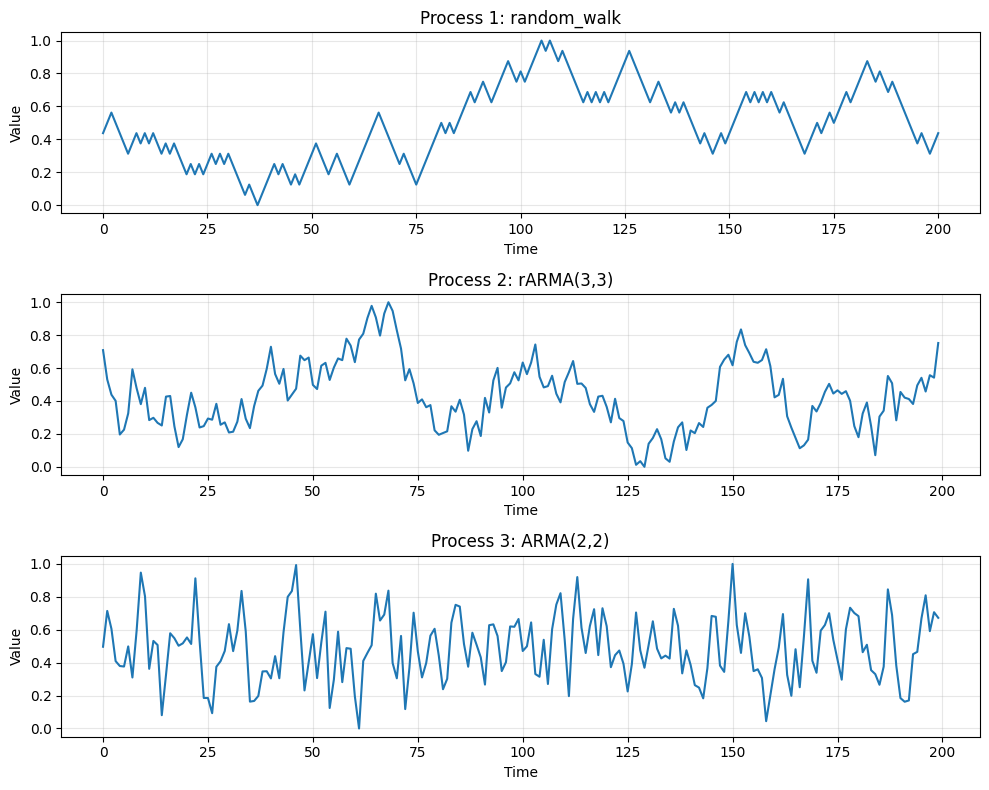

🔬 Demo: Advanced Process Analysis
🔬 Testing Process 2
----------------------------------------
Process 2 - rARMA(3,3):
  Successful trials: 5/5
  Signal shape per trial: 500
  Mean across 5 trials: 0.4691 ± 0.0774
  Average std across trials: 0.1554
  Range of means: [0.4262, 0.5172]


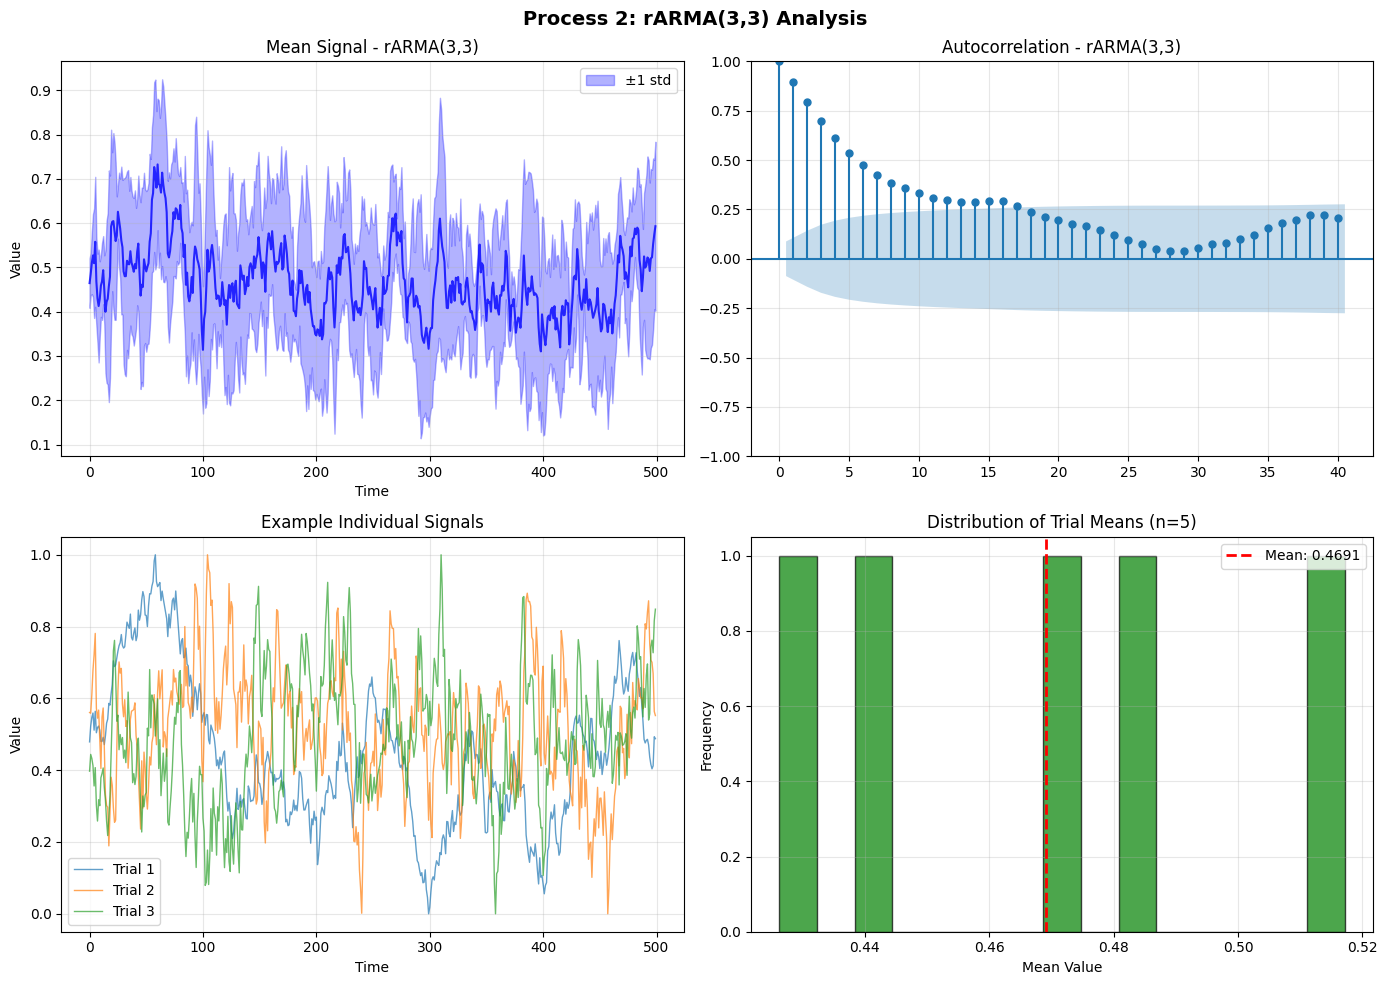

📊 Demo: Process Comparison
📊 Comparing All Processes

🔍 Testing Process 1...
🔬 Testing Process 1
----------------------------------------
Process 1 - random_walk:
  Successful trials: 3/3
  Signal shape per trial: 501
  Mean across 3 trials: 0.5031 ± 0.1485
  Average std across trials: 0.1997
  Range of means: [0.3826, 0.5686]

🔍 Testing Process 2...
🔬 Testing Process 2
----------------------------------------
Process 2 - rARMA(3,3):
  Successful trials: 3/3
  Signal shape per trial: 500
  Mean across 3 trials: 0.4820 ± 0.0947
  Average std across trials: 0.1447
  Range of means: [0.4441, 0.5172]

🔍 Testing Process 3...
🔬 Testing Process 3
----------------------------------------
Process 3 - ARMA(2,2):
  Successful trials: 3/3
  Signal shape per trial: 500
  Mean across 3 trials: 0.5455 ± 0.0887
  Average std across trials: 0.1139
  Range of means: [0.5253, 0.5619]


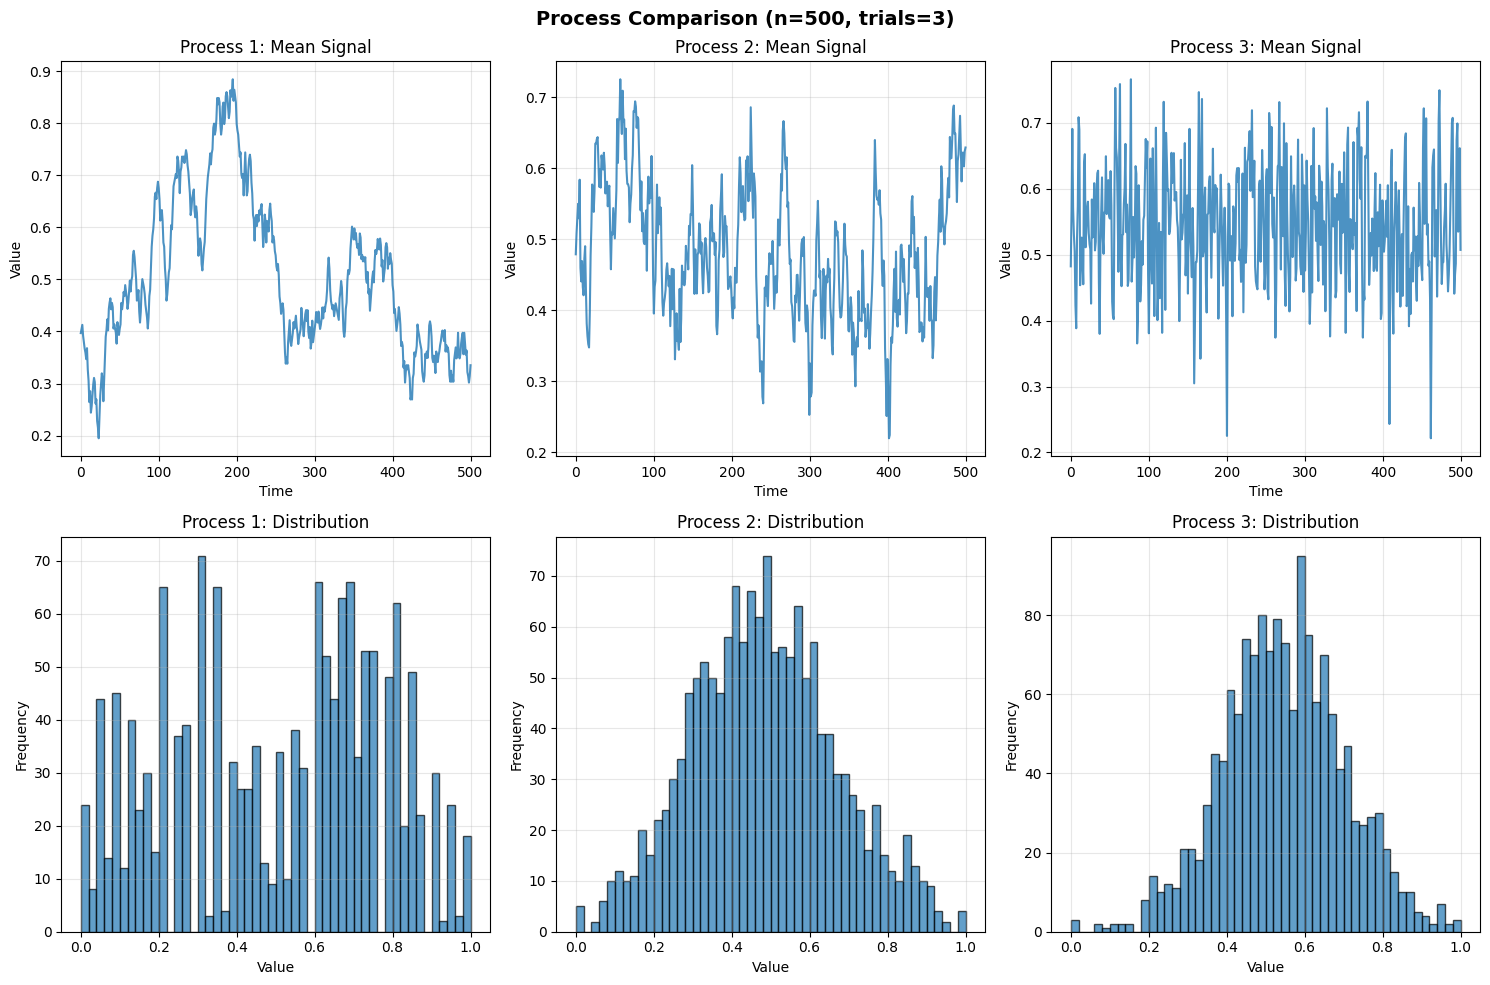


📈 Summary Statistics

Process 1:
  Total samples: 1,503
  Global mean: 0.5031
  Global std: 0.2687
  Min: 0.0000
  Max: 1.0000
  25th percentile: 0.2609
  75th percentile: 0.7273

Process 2:
  Total samples: 1,500
  Global mean: 0.4820
  Global std: 0.1855
  Min: 0.0000
  Max: 1.0000
  25th percentile: 0.3495
  75th percentile: 0.6045

Process 3:
  Total samples: 1,500
  Global mean: 0.5455
  Global std: 0.1561
  Min: 0.0000
  Max: 1.0000
  25th percentile: 0.4427
  75th percentile: 0.6485
🧪 Testing Time Series Generators

Testing: Random Walk (n=100)
  ✓ Generated: random_walk
  ✓ Shape: torch.Size([101])
  ✓ Range: [0.0000, 1.0000]
  ✓ Mean: 0.4095, Std: 0.2208
  ✓ Normalization: Correct [0, 1] range
  ✓ No NaN/Inf values

Testing: Random ARMA(3,3) (n=1000)
  ✓ Generated: rARMA(3,3)
  ✓ Shape: torch.Size([1000])
  ✓ Range: [0.0000, 1.0000]
  ✓ Mean: 0.4285, Std: 0.1507
  ✓ Normalization: Correct [0, 1] range
  ✓ No NaN/Inf values

Testing: Fixed ARMA(2,2) (n=500)
  ✓ Generated: ARMA

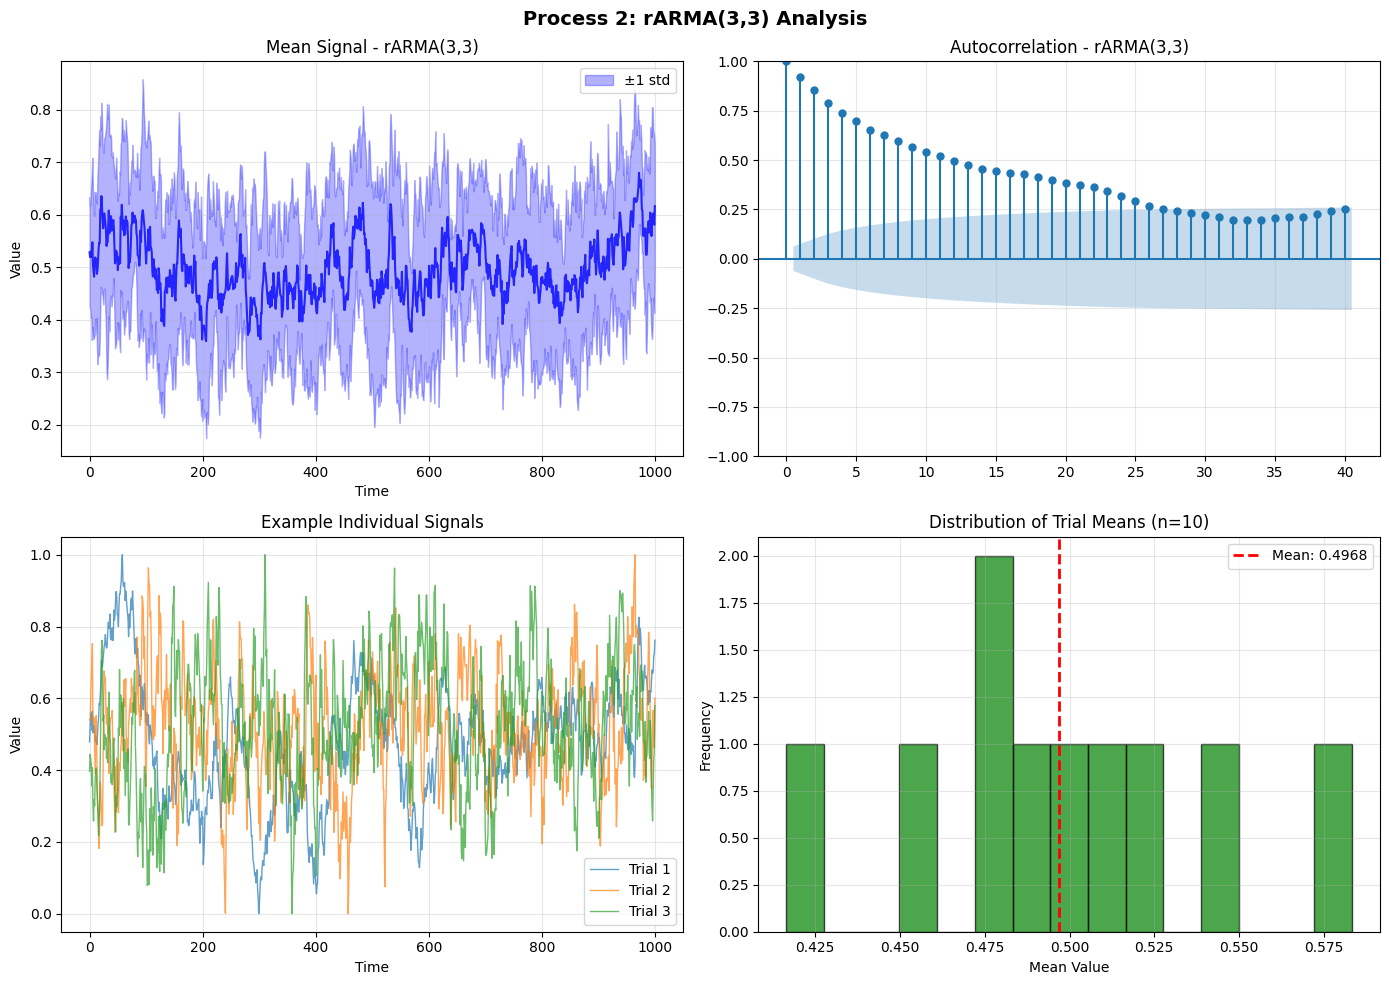

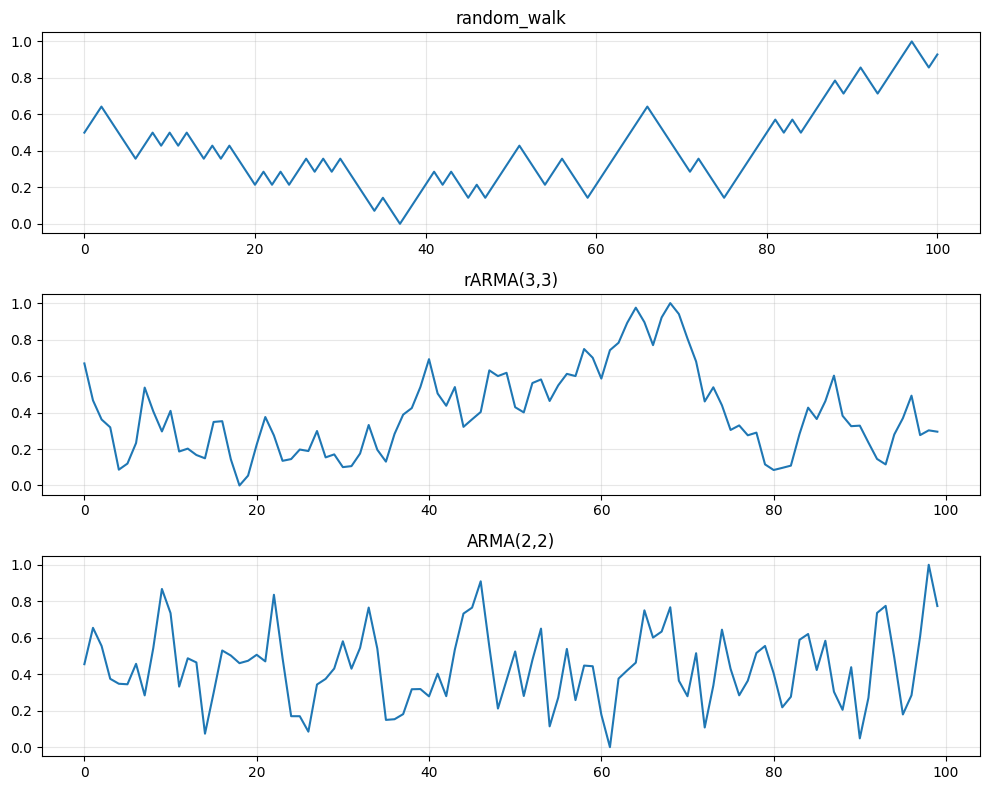

Testing Process 2 with 500 samples, 8 trials
🔬 Testing Process 2
----------------------------------------
Process 2 - rARMA(3,3):
  Successful trials: 8/8
  Signal shape per trial: 500
  Mean across 8 trials: 0.4796 ± 0.0721
  Average std across trials: 0.1643
  Range of means: [0.4089, 0.5413]


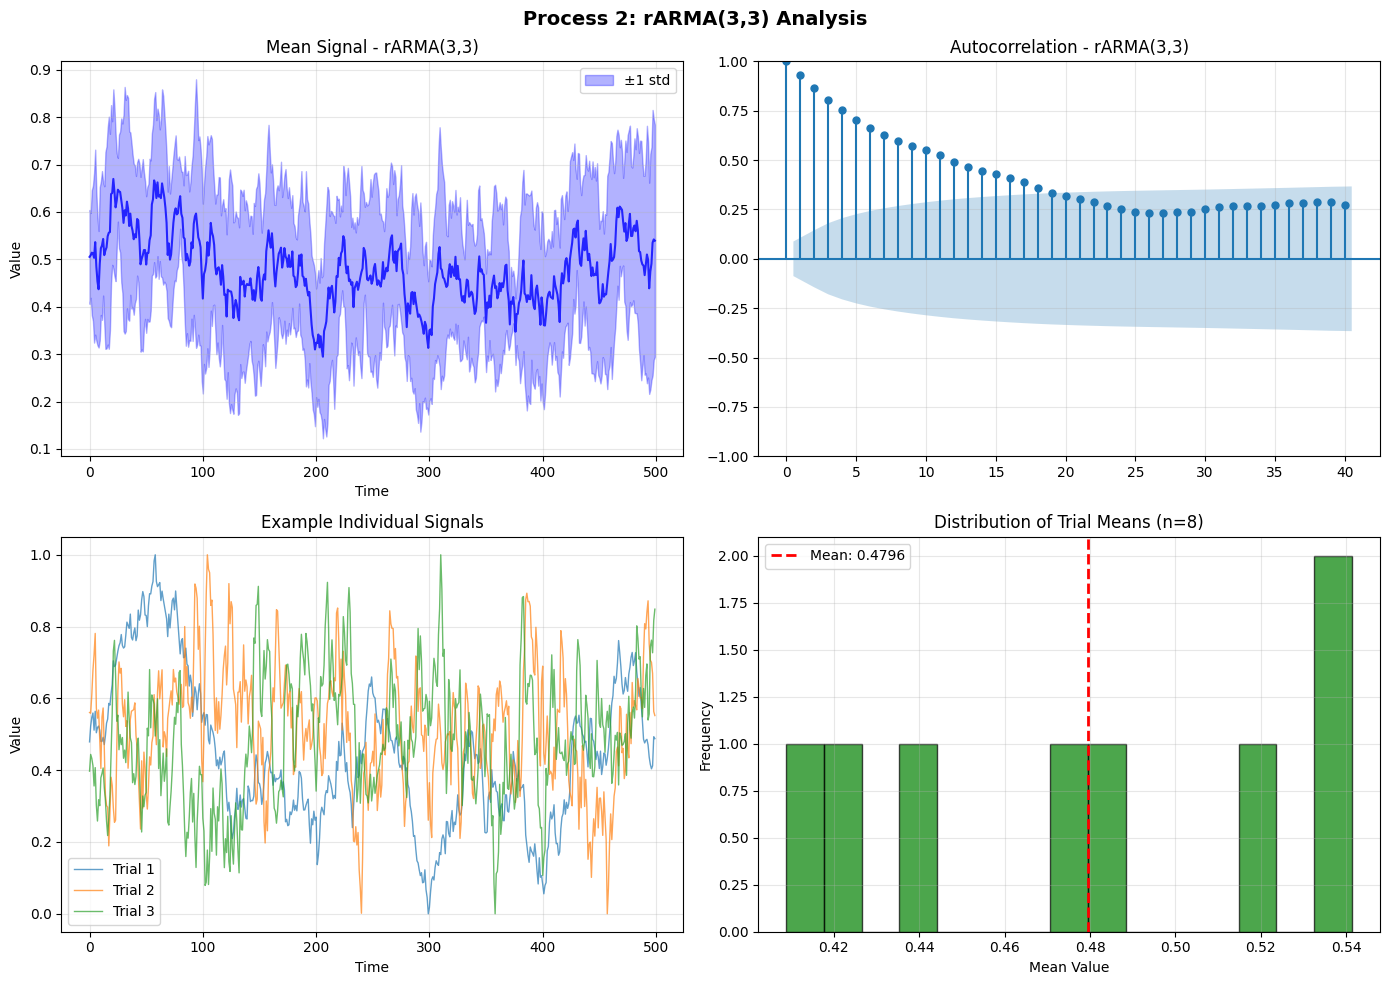


📈 Summary Statistics

Process 1:
  Total samples: 500
  Global mean: 0.5172
  Global std: 0.1688
  Min: 0.0000
  Max: 1.0000
  25th percentile: 0.4054
  75th percentile: 0.6186


In [4]:
# ─────────────────────────────────────────────
# Jupyter Notebook Cells
# ─────────────────────────────────────────────

# Cell 1: Load the code above

# Cell 2: Basic demo
# demo_basic()

# Cell 3: Test specific process
# signals = test_specific_process(process=2, n_samples=1000, n_trials=10, plot_acf=True)

# Cell 4: Compare all processes
# compare_all_processes(n_samples=500, n_trials=5, save_plots=False)

# Cell 5: Quick test
# test_generators()

# Cell 6: Generate individual time series
# signal1, label1 = timeseries(100, 1, seed=42)
# signal2, label2 = timeseries(100, 2, seed=42)
# signal3, label3 = timeseries(100, 3, seed=42)

for i in range(1, 5):
    if i == 1:  # Run Demo Functions
        # Run basic demo
        demo_basic()

        # Run advanced analysis
        signals = demo_advanced()

        # Run comparison
        demo_comparison()
    if i== 2:  # Run Individual Tests
        # Basic functionality test
        test_generators()
        # Generate individual time series
        # Test specific process with ACF plots
        signals = test_specific_process(
            process=2,           # Process ID: 1, 2, or 3
            n_samples=1000,      # Samples per trial
            n_trials=10,         # Number of trials
            plot_acf=True        # Show autocorrelation plots
        )
    if i == 3:  # Direct Usage
        # Generate individual time series
        signal1, label1 = timeseries(100, 1, seed=42)  # Random Walk
        signal2, label2 = timeseries(100, 2, seed=42)  # Random ARMA
        signal3, label3 = timeseries(100, 3, seed=42)  # Fixed ARMA

        # Plot them
        fig, axes = plt.subplots(3, 1, figsize=(10, 8))
        for idx, (signal, label) in enumerate([(signal1, label1), (signal2, label2), (signal3, label3)]):
            axes[idx].plot(signal.numpy())
            axes[idx].set_title(label)
            axes[idx].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    if i == 4:  # Interactive Testing
        # Generate individual time series
        # Interactive testing cell
        process_id = 2  # Change this to 1, 2, or 3
        n_samples = 500
        n_trials = 8

        print(f"Testing Process {process_id} with {n_samples} samples, {n_trials} trials")
        signals = test_specific_process(
        process=process_id,
        n_samples=n_samples,
        n_trials=n_trials,
        plot_acf=True
        )

        # Print summary statistics
        print("\n" + "=" * 50)
        print("📈 Summary Statistics")
        print("=" * 50)

        for process in [1, 2, 3]:
            if process in signals:
                signals = signals[process]
                flat_signals = signals.flatten()

                print(f"\nProcess {process}:")
                print(f"  Total samples: {len(flat_signals):,}")
                print(f"  Global mean: {flat_signals.mean():.4f}")
                print(f"  Global std: {flat_signals.std():.4f}")
                print(f"  Min: {flat_signals.min():.4f}")
                print(f"  Max: {flat_signals.max():.4f}")
                print(f"  25th percentile: {np.percentile(flat_signals, 25):.4f}")
                print(f"  75th percentile: {np.percentile(flat_signals, 75):.4f}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=77bc1c5c-a916-4b0d-b67e-f412197c3c90' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>